# COURSE: A deep understanding of deep learning
## SECTION: Generative adversarial networks
### LECTURE: Linear GAN with MNIST
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [66]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import sys

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import the data

In [56]:
import torchvision.datasets as datasets
mnist_train = datasets.FashionMNIST(root='./data', train=True, download=True)
mnist_test = datasets.FashionMNIST(root='./data', train=False, download=True)

train_data = mnist_train.data
train_labels = mnist_train.targets
test_data = mnist_test.data
test_labels = mnist_test.targets

# reshape data to 2D tensor
train_data = train_data.reshape(-1, 28*28).float()
test_data = test_data.reshape(-1, 28*28).float()

# selected labels (trousers, sneakers and ?)
pullover_labels = [1, 7, 2]
sandals_labels = [1, 7, 5]

pullover_train_indices = torch.where(torch.isin(train_labels, torch.tensor(pullover_labels)))[0]
pullover_test_indices = torch.where(torch.isin(test_labels, torch.tensor(pullover_labels)))[0]
sandals_train_indices = torch.where(torch.isin(train_labels, torch.tensor(sandals_labels)))[0]
sandals_test_indices = torch.where(torch.isin(test_labels, torch.tensor(sandals_labels)))[0]

print(pullover_train_indices)

# subdata 
pullover_train_data = train_data[pullover_train_indices]
pullover_train_labels = train_labels[pullover_train_indices]
pullover_test_data = test_data[pullover_test_indices]
pullover_test_labels = test_labels[pullover_test_indices]

sandals_train_data = train_data[sandals_train_indices]
sandals_train_labels = train_labels[sandals_train_indices]
sandals_test_data = test_data[sandals_test_indices]
sandals_test_labels = test_labels[sandals_test_indices]

# normalize the data to a range of [-1 1] (b/c tanh output)
pullover_train_dataNorm = pullover_train_data / np.max(pullover_train_data.numpy())
pullover_train_dataNorm = 2*pullover_train_dataNorm - 1
pullover_test_dataNorm = pullover_test_data / np.max(pullover_test_data.numpy())
pullover_test_dataNorm = 2*pullover_test_dataNorm - 1

sandals_train_dataNorm = sandals_train_data / np.max(sandals_train_data.numpy())
sandals_train_dataNorm = 2*sandals_train_dataNorm - 1
sandals_test_dataNorm = sandals_test_data / np.max(sandals_test_data.numpy())
sandals_test_dataNorm = 2*sandals_test_dataNorm - 1

pullover_train_dataT = torch.tensor(pullover_train_dataNorm)
pullover_test_dataT = torch.tensor(pullover_test_dataNorm)
sandals_train_dataT = torch.tensor(sandals_train_dataNorm)
sandals_test_dataT = torch.tensor(sandals_test_dataNorm)

# Create dataloaders 
pullover_train_dataset = TensorDataset(pullover_train_dataT, pullover_train_labels)
pullover_test_dataset = TensorDataset(pullover_test_dataT, pullover_test_labels)

sandals_train_dataset = TensorDataset(sandals_train_dataT, sandals_train_labels)
sandals_test_dataset = TensorDataset(sandals_test_dataT, sandals_test_labels)

batchsize = 100
pullover_train_loader = DataLoader(pullover_train_dataset, batch_size=batchsize, shuffle=True)
pullover_test_loader = DataLoader(pullover_test_dataset, batch_size=pullover_test_dataset.tensors[0].shape[0], shuffle=False)

sandals_train_loader = DataLoader(sandals_train_dataset, batch_size=batchsize, shuffle=True)
sandals_test_loader = DataLoader(sandals_test_dataset, batch_size=sandals_test_dataset.tensors[0].shape[0], shuffle=False)

tensor([    5,     6,     7,  ..., 59992, 59993, 59996])


/tmp/ipykernel_4283/3669125011.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pullover_train_dataT = torch.tensor(pullover_train_dataNorm)
/tmp/ipykernel_4283/3669125011.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pullover_test_dataT = torch.tensor(pullover_test_dataNorm)
/tmp/ipykernel_4283/3669125011.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sandals_train_dataT = torch.tensor(sandals_train_dataNorm)
/tmp/ipykernel_4283/3669125011.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sour

# Create classes for the discriminator and generator

In [57]:
class discriminatorNet(nn.Module):
  def __init__(self):
    super().__init__()
    
    self.fc1 = nn.Linear(28*28,256)
    self.fc2 = nn.Linear(256,256)
    self.out = nn.Linear(256,1)

  def forward(self,x):
    x = F.leaky_relu( self.fc1(x) )
    x = F.leaky_relu( self.fc2(x) )
    x = self.out(x)
    return torch.sigmoid( x )

dnet = discriminatorNet()
y = dnet(torch.randn(10,784))
y

tensor([[0.5324],
        [0.5206],
        [0.5334],
        [0.5135],
        [0.5047],
        [0.5397],
        [0.5196],
        [0.5025],
        [0.4736],
        [0.4953]], grad_fn=<SigmoidBackward0>)

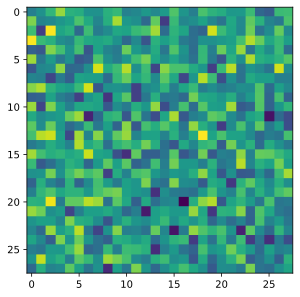

In [58]:
class generatorNet(nn.Module):
  def __init__(self):
    super().__init__()
    
    self.fc1 = nn.Linear(64,256)
    self.fc2 = nn.Linear(256,256)
    self.out = nn.Linear(256,784)

  def forward(self,x):
    x = F.leaky_relu( self.fc1(x) )
    x = F.leaky_relu( self.fc2(x) )
    x = self.out(x)
    return torch.tanh( x )


gnet = generatorNet()
y = gnet(torch.randn(10,64))
plt.imshow(y[0,:].detach().squeeze().view(28,28));

# Train the models!

In [67]:
# loss function (same for both phases of training)
lossfun = nn.BCELoss()

# create instances of the models
dnet_pullover = discriminatorNet().to(device)
dnet_sandals = discriminatorNet().to(device)
gnet_pullover = generatorNet().to(device)
gnet_sandals = generatorNet().to(device)

# optimizers (same algo but different variables b/c different parameters)
d_optimizer_pullover = torch.optim.Adam(dnet_pullover.parameters(), lr=.0003)
g_optimizer_pullover = torch.optim.Adam(gnet_pullover.parameters(), lr=.0003)
d_optimizer_sandals = torch.optim.Adam(dnet_sandals.parameters(), lr=.0003)
g_optimizer_sandals = torch.optim.Adam(gnet_sandals.parameters(), lr=.0003)

# Train pullover

Finished epoch 50/500

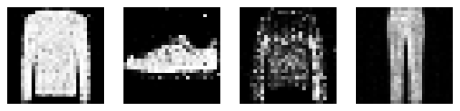

Finished epoch 100/500

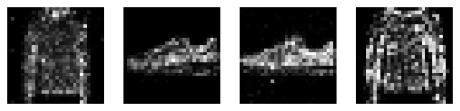

Finished epoch 150/500

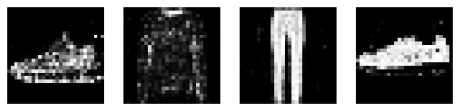

Finished epoch 200/500

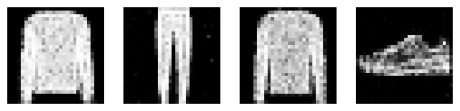

Finished epoch 250/500

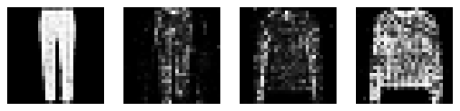

Finished epoch 300/500

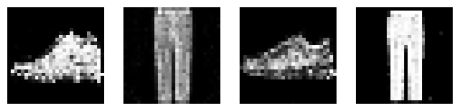

Finished epoch 350/500

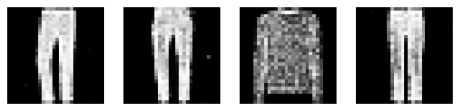

Finished epoch 400/500

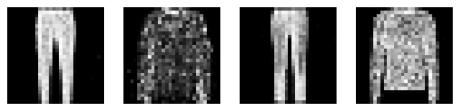

Finished epoch 450/500

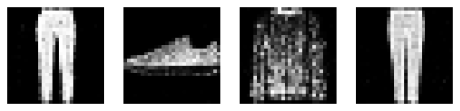

Finished epoch 500/500

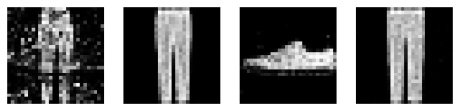

In [74]:
num_epochs = int(50000/ len(pullover_train_loader))

losses_pullover  = np.zeros((num_epochs,2))
disDecs_pullover = np.zeros((num_epochs,2)) # disDecs = discriminator decisions

for epochi in range(num_epochs):

  for real_images, labels in pullover_train_loader:
    # we don't need the labels for training the GAN

    real_images = real_images.to(device) # move images to GPU if available
    fake_images = gnet_pullover( torch.randn(batchsize,64).to(device) ) # output of generator

    # labels used for real and fake images
    real_labels = torch.ones(batchsize,1).to(device)
    fake_labels = torch.zeros(batchsize,1).to(device)


    ### ---------------- Train the discriminator ---------------- ###

    # forward pass and loss for REAL pictures
    pred_real   = dnet_pullover(real_images)              # REAL images into discriminator
    d_loss_real = lossfun(pred_real,real_labels)          # all labels are 1
    
    # forward pass and loss for FAKE pictures
    pred_fake   = dnet_pullover(fake_images)              # FAKE images into discriminator
    d_loss_fake = lossfun(pred_fake,fake_labels)          # all labels are 0
    
    # collect loss (using combined losses)
    d_loss = d_loss_real + d_loss_fake # we could bias this if needed
    losses_pullover[epochi,0]  = d_loss.item()
    disDecs_pullover[epochi,0] = torch.mean((pred_real>.5).float()).detach()

    # backprop
    d_optimizer_pullover.zero_grad()
    d_loss.backward()
    d_optimizer_pullover.step()

    ### ---------------- Train the generator ---------------- ###

    # create fake images and compute loss
    fake_images = gnet_pullover( torch.randn(batchsize,64).to(device) )
    pred_fake   = dnet_pullover(fake_images)

    # compute and collect loss and accuracy
    g_loss = lossfun(pred_fake,real_labels) # we are saying these are real! We are lying to reduce the loss
    losses_pullover[epochi,1]  = g_loss.item()
    disDecs_pullover[epochi,1] = torch.mean((pred_fake>.5).float()).detach()
    
    # backprop
    g_optimizer_pullover.zero_grad()
    g_loss.backward()
    g_optimizer_pullover.step()

  
  # print out a status message
  msg = f'Finished epoch {epochi+1}/{num_epochs}'
  sys.stdout.write('\r' + msg)
  
  # print image every 50 epochs
  if (epochi+1)%50==0:
    gnet_pullover.eval()
    fake_data = gnet_pullover(torch.randn(4,64).to(device)).cpu()

    # and visualize...
    fig,axs = plt.subplots(1,4,figsize=(8,2))
    for i,ax in enumerate(axs.flatten()):
      ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
      ax.axis('off')

    plt.show()

    gnet_pullover.train()

# Train sandals

Finished epoch 50/277

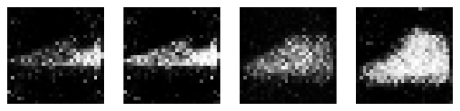

Finished epoch 100/277

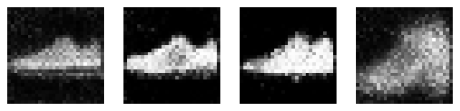

Finished epoch 150/277

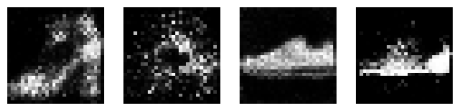

Finished epoch 200/277

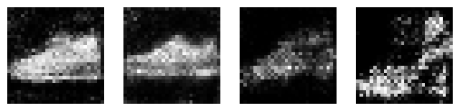

Finished epoch 250/277

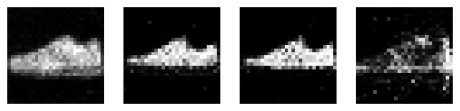

Finished epoch 277/277

In [78]:
# num_epochs = 50000
num_epochs = int(50000/ len(sandals_train_loader)) 

losses_sandals  = np.zeros((num_epochs,2))
disDecs_sandals = np.zeros((num_epochs,2)) # disDecs = discriminator decisions

for epochi in range(num_epochs):
  for real_images, labels in sandals_train_loader:
    # we don't need the labels for training the GAN

    # create minibatches of REAL and FAKE images
    real_images = real_images.to(device) # move images to GPU if available
    fake_images = gnet_sandals( torch.randn(batchsize,64).to(device) ) # output of generator


    # labels used for real and fake images
    real_labels = torch.ones(batchsize,1).to(device)
    fake_labels = torch.zeros(batchsize,1).to(device)



    ### ---------------- Train the discriminator ---------------- ###

    # forward pass and loss for REAL pictures
    pred_real   = dnet_sandals(real_images)              # REAL images into discriminator
    d_loss_real = lossfun(pred_real,real_labels) # all labels are 1
    
    # forward pass and loss for FAKE pictures
    pred_fake   = dnet_sandals(fake_images)              # FAKE images into discriminator
    d_loss_fake = lossfun(pred_fake,fake_labels) # all labels are 0
    
    # collect loss (using combined losses)
    d_loss = d_loss_real + d_loss_fake # we could bias this if needed
    losses_sandals[epochi,0]  = d_loss.item()
    disDecs_sandals[epochi,0] = torch.mean((pred_real>.5).float()).detach()

    # backprop
    d_optimizer_sandals.zero_grad()
    d_loss.backward()
    d_optimizer_sandals.step()

    ### ---------------- Train the generator ---------------- ###

    # create fake images and compute loss
    fake_images = gnet_sandals( torch.randn(batchsize,64).to(device) )
    pred_fake   = dnet_sandals(fake_images)

    # compute and collect loss and accuracy
    g_loss = lossfun(pred_fake,real_labels) # we are saying these are real! We are lying to reduce the loss
    losses_sandals[epochi,1]  = g_loss.item()
    disDecs_sandals[epochi,1] = torch.mean((pred_fake>.5).float()).detach()

    # backprop
    g_optimizer_sandals.zero_grad()
    g_loss.backward()
    g_optimizer_sandals.step()

  
  # print out a status message
  msg = f'Finished epoch {epochi+1}/{num_epochs}'
  sys.stdout.write('\r' + msg)
  
  # print image every 5000 epochs
  if (epochi+1)%50==0:
    gnet_sandals.eval()
    fake_data = gnet_sandals(torch.randn(4,64).to(device)).cpu()

    # and visualize...
    fig,axs = plt.subplots(1,4,figsize=(8,2))
    for i,ax in enumerate(axs.flatten()):
      ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
      ax.axis('off')

    plt.show()

    gnet_sandals.train()

In [83]:
window = 10  # smoothing window size
smooth_losses_pullover_discriminator = np.convolve(losses_pullover[:,0], np.ones(window)/window, mode='valid')
smooth_losses_pullover_generator = np.convolve(losses_pullover[:,1], np.ones(window)/window, mode='valid')
smooth_losses_sandals_discriminator = np.convolve(losses_sandals[:,0], np.ones(window)/window, mode='valid')
smooth_losses_sandals_generator = np.convolve(losses_sandals[:,1], np.ones(window)/window, mode='valid')

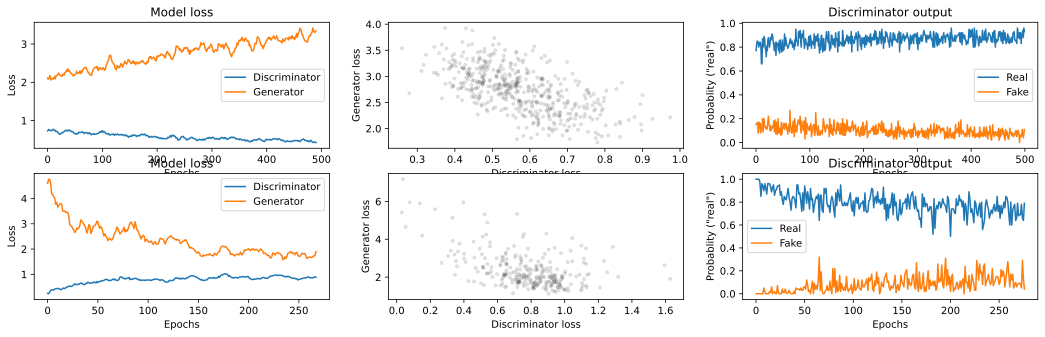

In [84]:
fig,ax = plt.subplots(2,3,figsize=(18,5))

ax[0][0].plot(smooth_losses_pullover_discriminator, label='Discriminator')
ax[0][0].plot(smooth_losses_pullover_generator, label='Generator')
ax[0][0].set_xlabel('Epochs')
ax[0][0].set_ylabel('Loss')
ax[0][0].set_title('Model loss')
ax[0][0].legend()

ax[0][1].plot(losses_pullover[:,0],losses_pullover[:,1],'k.',alpha=.1)
ax[0][1].set_xlabel('Discriminator loss')
ax[0][1].set_ylabel('Generator loss')

ax[0][2].plot(disDecs_pullover)
ax[0][2].set_xlabel('Epochs')
ax[0][2].set_ylabel('Probablity ("real")')
ax[0][2].set_title('Discriminator output')
ax[0][2].legend(['Real','Fake'])

ax[1][0].plot(smooth_losses_sandals_discriminator, label='Discriminator')
ax[1][0].plot(smooth_losses_sandals_generator, label='Generator')
ax[1][0].set_xlabel('Epochs')
ax[1][0].set_ylabel('Loss')
ax[1][0].set_title('Model loss')
ax[1][0].legend()

ax[1][1].plot(losses_sandals[:,0],losses_sandals[:,1],'k.',alpha=.1)
ax[1][1].set_xlabel('Discriminator loss')
ax[1][1].set_ylabel('Generator loss')

ax[1][2].plot(disDecs_sandals)
ax[1][2].set_xlabel('Epochs')
ax[1][2].set_ylabel('Probablity ("real")')
ax[1][2].set_title('Discriminator output')
ax[1][2].legend(['Real','Fake'])

plt.show()

# Let's see some fake digits!

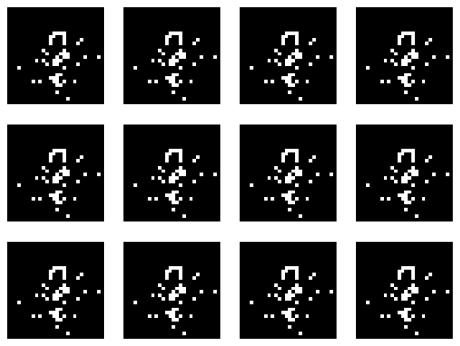

In [38]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()

# and visualize...
fig,axs = plt.subplots(3,4,figsize=(8,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
  ax.axis('off')

plt.show()